<a href="https://colab.research.google.com/github/rashmib21/RetailQ--E-Commerce-Sales-Analysis/blob/main/RetailIQ_E_Commerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install Plotly
!pip install plotly --quiet

#Import everything we need for the full project
import numpy as np   #Used for numerical operations and working with arrays.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')


#Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format','{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
#Load the Excel file (sheet 'Year 2009-2010' has the main data)

df=pd.read_csv('/content/online_retail_II.csv', encoding='latin-1')


#First look at the data
print("Shape: ",df.shape)
print("\nColumn names: ",df.columns.tolist())
print("\nFirst 5 rows: ")
df.head()


Shape:  (1067371, 8)

Column names:  ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows: 


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [3]:
#Check data types and missing values")
print('---------------------Data Types---------------------')
print(df.dtypes)

print("---------------------Missing Values---------------------")
print(df.isnull().sum())

print("---------------------Basic Stats---------------------")
print(df.describe())

---------------------Data Types---------------------
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
---------------------Missing Values---------------------
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
---------------------Basic Stats---------------------
        Quantity      Price  Customer ID
count 1067371.00 1067371.00    824364.00
mean        9.94       4.65     15324.64
std       172.71     123.55      1697.46
min    -80995.00  -53594.36     12346.00
25%         1.00       1.25     13975.00
50%         3.00       2.10     15255.00
75%        10.00       4.15     16797.00
max     80995.00   38970.00     18287.00


In [4]:
# Customer ID — 243007 nulls (Large value!)
# Description — 4382 nulls
# Quantity — negative values (min = -80995) → cancelled orders
# Price — negative values (min = -53594) → refunds
# InvoiceDate — object type, convert into datetime

print("---------------------Data Cleaning---------------------")

#Step 1: Note the original dataset original size
print(f"Original shape: {df.shape}")

#Step 2: InvoiceDate convert into datetime format
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
# print(f"After converting InvoiceDate: {df.dtypes['InvoiceDate']}")

#Step 3: Remove Cancelled order (that starts with 'C')
df=df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancelled orders: {df.shape}")


#Step 4: Remove negative quantity and price
df=df[df['Quantity']>0]
df=df[df['Price']>0]
print(f"After removing negative values: {df.shape}")

#Step 5:Remove description null values
df=df.dropna(subset=['Description'])
print(f"After removing null values: {df.shape}")

#Step 6: Remove customer id null values
df=df.dropna(subset=['Customer ID'])
print(f"After removing null ID's: {df.shape}")

#Step 7: Make revenue column
df['Revenue']=np.round(df['Quantity']*df['Price'],2)

#Step 8: Make month and year column
df['Month']=df['InvoiceDate'].dt.to_period('M')
df['Year']=df['InvoiceDate'].dt.year

#Step 9: Final cleaned data summary
print(f"\nFinal cleaned shape: {df.shape}")
print(f"\nNew columns added: {['Revenue', 'Month', 'Year']}")
print(f"\nRevenue column sample:")
print(df[['Invoice', 'Description', 'Quantity', 'Price', 'Revenue']].head())

---------------------Data Cleaning---------------------
Original shape: (1067371, 8)
After removing cancelled orders: (1047877, 8)
After removing negative values: (1041670, 8)
After removing null values: (1041670, 8)
After removing null ID's: (805549, 8)

Final cleaned shape: (805549, 11)

New columns added: ['Revenue', 'Month', 'Year']

Revenue column sample:
  Invoice                          Description  Quantity  Price  Revenue
0  489434  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   6.95    83.40
1  489434                   PINK CHERRY LIGHTS        12   6.75    81.00
2  489434                  WHITE CHERRY LIGHTS        12   6.75    81.00
3  489434         RECORD FRAME 7" SINGLE SIZE         48   2.10   100.80
4  489434       STRAWBERRY CERAMIC TRINKET BOX        24   1.25    30.00


In [5]:
print("---------------------Pandas EDA (Groupby + Analysis)---------------------")

#Monthly Revenue Trend
monthly_revenue=df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month']=monthly_revenue['Month'].astype(str)
print("---------------------Monthly revenue---------------------")
print(monthly_revenue)

#Top 10 Countries by Revenue
top_countries=df.groupby('Country')['Revenue'].sum()\
  .sort_values(ascending=False).head(10)
print('\n-----Top 10 Countries by Revenue-----')
print(top_countries)

#Top 10 Products by Quantity Sold
top_products = df.groupby('Description')['Quantity'].sum()\
                 .sort_values(ascending=False).head(10)
print("\n------ Top 10 Products by Quantity ------")
print(top_products)


#Step 4: Average order value
avg_order=df.groupby('Invoice')['Revenue'].sum()
print("\n------Average Order Values------")
print(f"Mean: £{avg_order.mean():.2f}")
print(f"Median: £{avg_order.median():.2f}")
print(f"Max: £{avg_order.max():.2f}")

#Step 5: NumPy-Outlier Detection
revenue_mean=np.mean(df['Revenue'])
revenue_std=np.std(df['Revenue'])
outliers=df[df['Revenue']>revenue_mean+3*revenue_std]
print(f"\n------NumPy outlier Detection------")
print(f"Total outlier transaction: {len(outliers)}")
print(f"Outlier revenue threshold: £{revenue_mean+3*revenue_std:.2f}")


---------------------Pandas EDA (Groupby + Analysis)---------------------
---------------------Monthly revenue---------------------
      Month    Revenue
0   2009-12  686654.16
1   2010-01  557319.06
2   2010-02  506371.06
3   2010-03  699608.99
4   2010-04  594609.19
5   2010-05  599985.79
6   2010-06  639066.58
7   2010-07  591636.74
8   2010-08  604242.65
9   2010-09  831615.00
10  2010-10 1036680.00
11  2010-11 1172336.04
12  2010-12  884591.89
13  2011-01  569445.04
14  2011-02  447137.35
15  2011-03  595500.76
16  2011-04  469200.36
17  2011-05  678594.56
18  2011-06  661213.69
19  2011-07  600091.01
20  2011-08  645343.90
21  2011-09  952838.38
22  2011-10 1039318.79
23  2011-11 1161817.38
24  2011-12  518210.79

-----Top 10 Countries by Revenue-----
Country
United Kingdom   14723147.50
EIRE               621631.11
Netherlands        554232.34
Germany            431262.46
France             355257.47
Australia          169968.11
Spain              109178.53
Switzerland        1

---------------------Matplotlib Charts---------------------


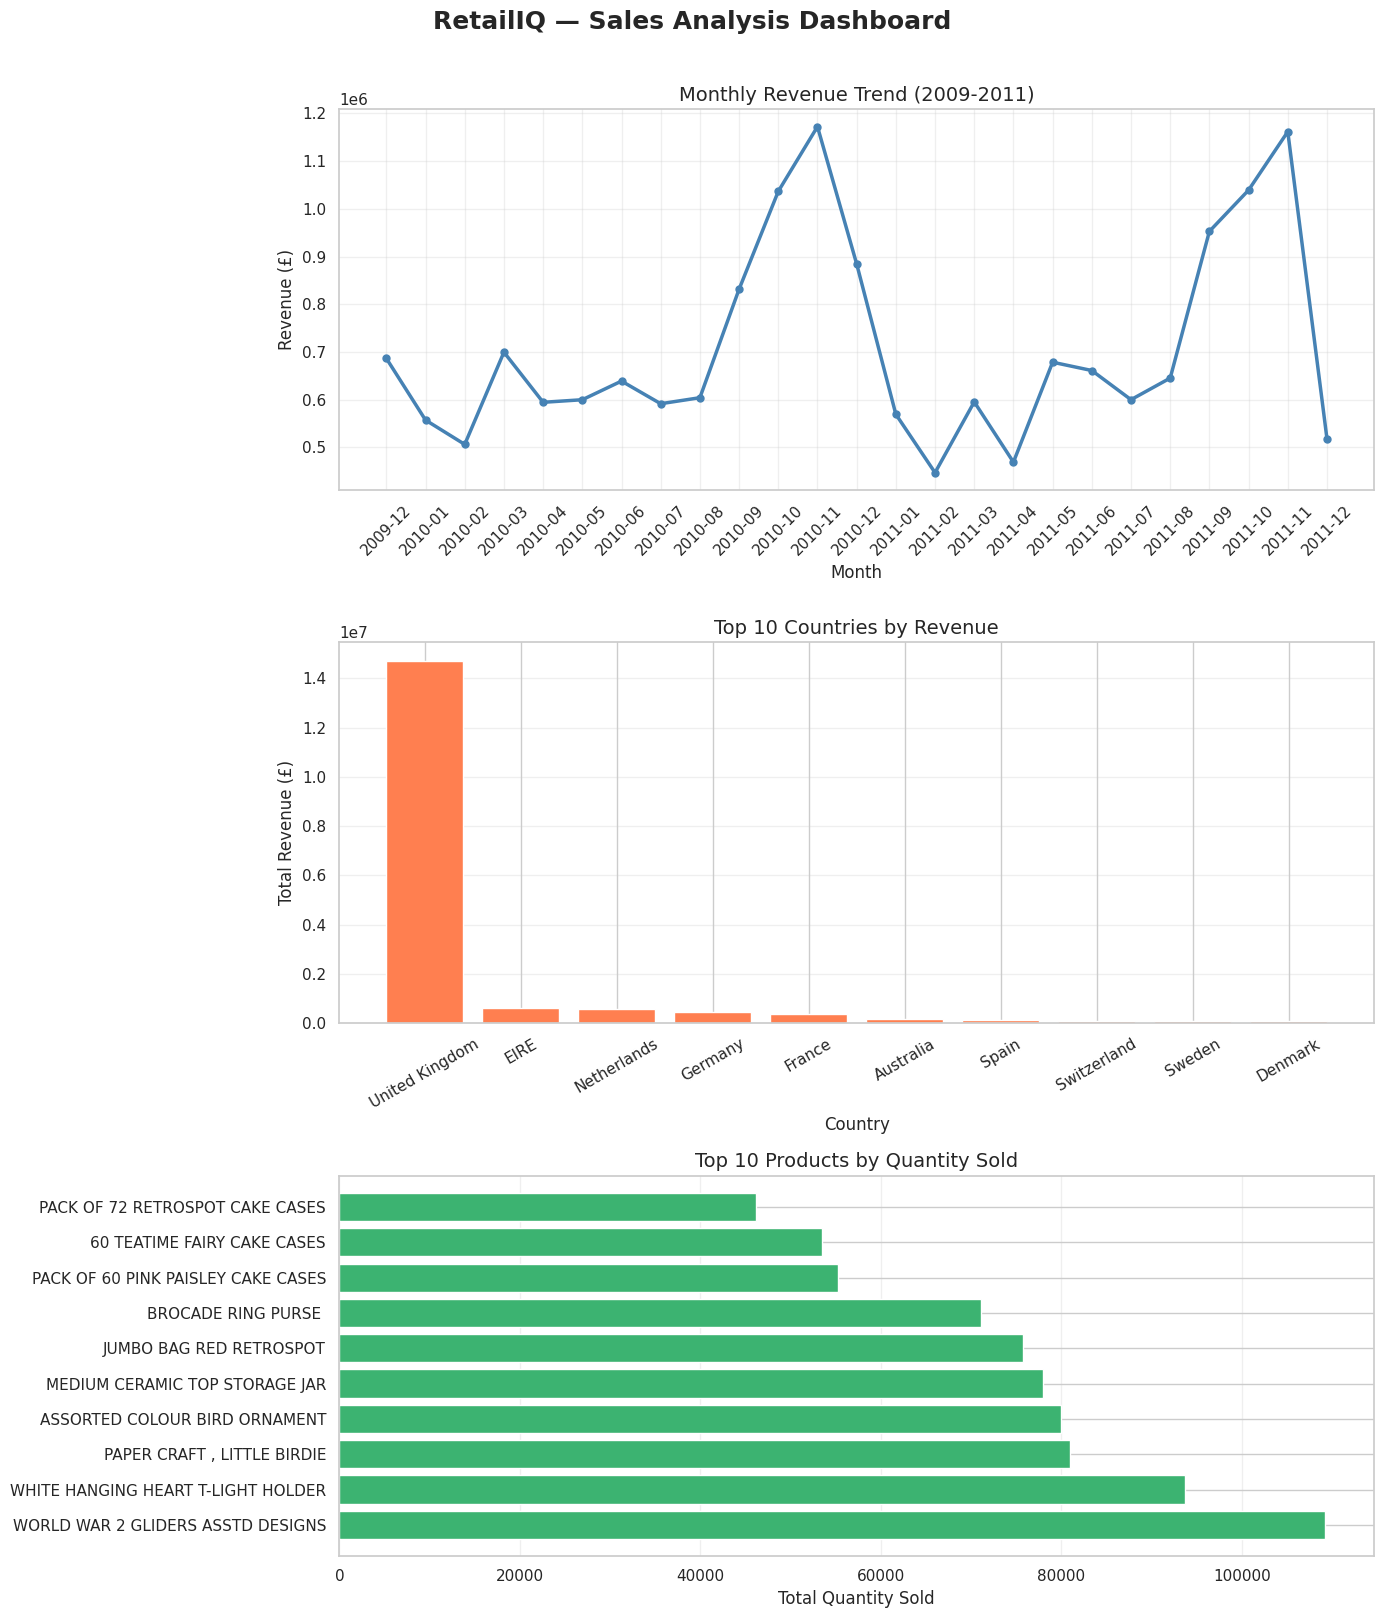

Chart saved!


In [6]:
print("---------------------Matplotlib Charts---------------------")


fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('RetailIQ — Sales Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Chart 1: Monthly Revenue Line Chart
axes[0].plot(monthly_revenue['Month'],
             monthly_revenue['Revenue'],
             color='steelblue', linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Monthly Revenue Trend (2009-2011)', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Chart 2: Top 10 Countries Bar Chart
axes[1].bar(top_countries.index, top_countries.values,
            color='coral', edgecolor='white')
axes[1].set_title('Top 10 Countries by Revenue', fontsize=14)
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Chart 3: Top 10 Products Horizontal Bar Chart
axes[2].barh(top_products.index, top_products.values,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Top 10 Products by Quantity Sold', fontsize=14)
axes[2].set_xlabel('Total Quantity Sold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('matplotlib_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")